## Step 3 — MIMII Data Preprocessing
**Dissertation: TinyML-Based Anomaly Detection**  
**Author: Thondupu Dileep | 2024AB05233**

Loads .wav audio files → log-Mel spectrograms → normalise → save .npz

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

NORMAL_DIR   = '../MIMII/normal'
ABNORMAL_DIR = '../MIMII/abnormal'
OUT_DIR      = '../data/processed'

SR          = 16000
DURATION    = 10.0
N_MELS      = 64
HOP_LENGTH  = 512
N_FFT       = 1024
TRAIN_RATIO = 0.8

os.makedirs(OUT_DIR, exist_ok=True)
print('Ready')

Ready


### 3.1 — Load one file and inspect

Sample rate : 16000 Hz
Duration    : 10.0 seconds
Samples     : 160,000
Amplitude   : min=-0.0327  max=0.0322


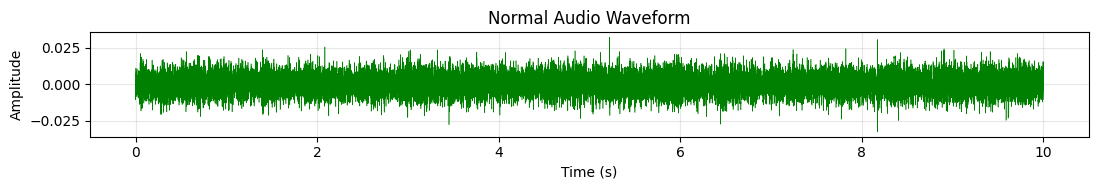

In [2]:
sample_file = os.path.join(NORMAL_DIR, '00000000.wav')
audio, sr   = librosa.load(sample_file, sr=SR, mono=True)

print(f'Sample rate : {sr} Hz')
print(f'Duration    : {len(audio)/sr:.1f} seconds')
print(f'Samples     : {len(audio):,}')
print(f'Amplitude   : min={audio.min():.4f}  max={audio.max():.4f}')

plt.figure(figsize=(11, 2))
plt.plot(np.arange(len(audio))/sr, audio, linewidth=0.4, color='green')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Normal Audio Waveform')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 — Log-Mel spectrogram

In [3]:
def to_log_mel(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)

    # pad or trim to fixed length
    target = int(SR * DURATION)
    if len(audio) < target:
        audio = np.pad(audio, (0, target - len(audio)))
    else:
        audio = audio[:target]

    mel = librosa.feature.melspectrogram(y=audio, sr=SR,
                                          n_fft=N_FFT,
                                          hop_length=HOP_LENGTH,
                                          n_mels=N_MELS)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)

mel_n = to_log_mel(os.path.join(NORMAL_DIR,   '00000000.wav'))
mel_a = to_log_mel(os.path.join(ABNORMAL_DIR, '00000000.wav'))

print(f'Spectrogram shape: {mel_n.shape}   ({N_MELS} mel bands x {mel_n.shape[1]} time frames)')
print(f'Value range: min={mel_n.min():.1f} dB  max={mel_n.max():.1f} dB')

Spectrogram shape: (64, 313)   (64 mel bands x 313 time frames)
Value range: min=-47.3 dB  max=0.0 dB


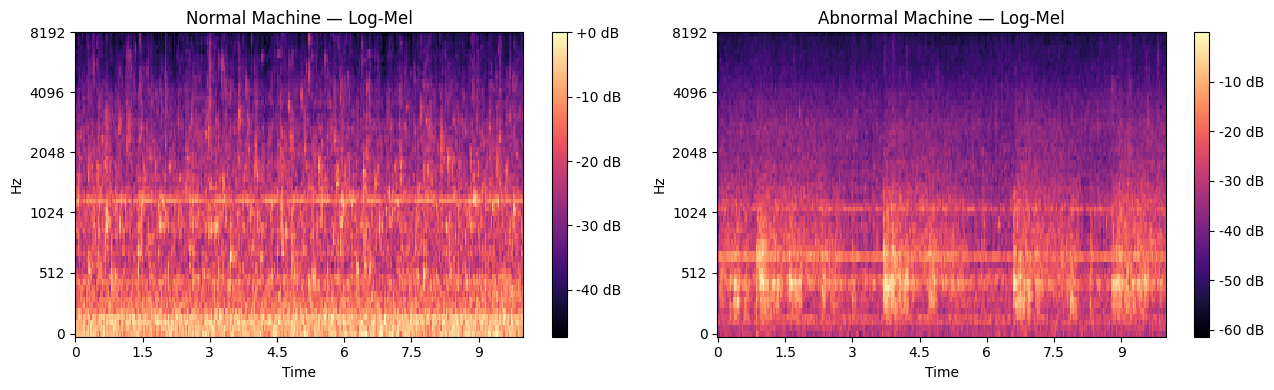

In [4]:
# side-by-side spectrogram comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

img1 = librosa.display.specshow(mel_n, sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel', ax=axes[0])
axes[0].set_title('Normal Machine — Log-Mel')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

img2 = librosa.display.specshow(mel_a, sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('Abnormal Machine — Log-Mel')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

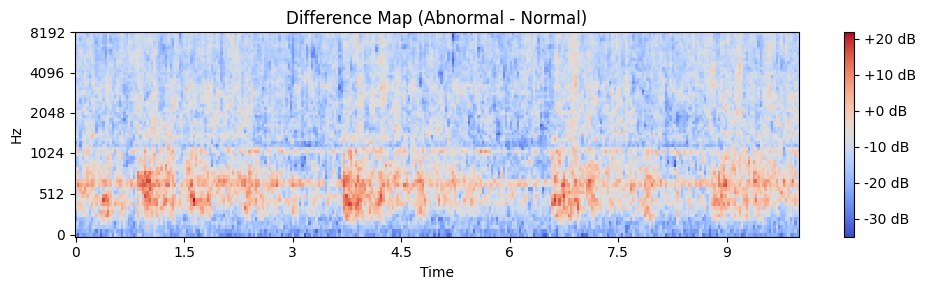

Max positive diff: 21.80 dB
Max negative diff: -35.00 dB


In [10]:
# difference map — shows what changed
diff = mel_a - mel_n

fig, ax = plt.subplots(figsize=(10, 3))
img = librosa.display.specshow(diff, sr=SR, hop_length=HOP_LENGTH,
                                x_axis='time', y_axis='mel', ax=ax, cmap='coolwarm')
ax.set_title('Difference Map (Abnormal - Normal)')
fig.colorbar(img, ax=ax, format='%+2.0f dB')
plt.tight_layout()
plt.show()

print(f'Max positive diff: {diff.max():.2f} dB')
print(f'Max negative diff: {diff.min():.2f} dB')

### 3.3 — Process all files

In [11]:
def load_folder(folder, label):
    files = sorted([f for f in os.listdir(folder) if f.endswith('.wav')])
    specs = []
    for i, fname in enumerate(files):
        specs.append(to_log_mel(os.path.join(folder, fname)))
        if (i+1) % 50 == 0:
            print(f'  {i+1}/{len(files)} done')
    return np.array(specs, dtype=np.float32), np.full(len(specs), label, dtype=np.int32)

print('Loading normal files...')
X_normal, y_normal = load_folder(NORMAL_DIR, label=0)

print('\nLoading abnormal files...')
X_abnormal, y_abnormal = load_folder(ABNORMAL_DIR, label=1)

print(f'\nNormal   : {X_normal.shape}')
print(f'Abnormal : {X_abnormal.shape}')

Loading normal files...
  50/381 done
  100/381 done
  150/381 done
  200/381 done
  250/381 done
  300/381 done
  350/381 done

Loading abnormal files...
  50/138 done
  100/138 done

Normal   : (381, 64, 313)
Abnormal : (138, 64, 313)


### 3.4 — Train / Validation split

In [7]:
# shuffle normal data before splitting
rng = np.random.default_rng(42)
idx = rng.permutation(len(X_normal))
X_normal = X_normal[idx]

split   = int(len(X_normal) * TRAIN_RATIO)
X_train = X_normal[:split]    # only normal — train autoencoder on this
X_val   = X_normal[split:]    # held-out normal

print(f'Train (normal only): {len(X_train)}')
print(f'Val   (normal only): {len(X_val)}')
print(f'Test  (abnormal)   : {len(X_abnormal)}')

Train (normal only): 304
Val   (normal only): 77
Test  (abnormal)   : 138


### 3.5 — Normalisation

In [8]:
# global mean and std from training normal data only
mu    = X_train.mean()
sigma = X_train.std() + 1e-8

print(f'Mean (train normal): {mu:.4f} dB')
print(f'Std  (train normal): {sigma:.4f} dB')

X_train_norm    = ((X_train    - mu) / sigma).astype(np.float32)
X_val_norm      = ((X_val      - mu) / sigma).astype(np.float32)
X_abnormal_norm = ((X_abnormal - mu) / sigma).astype(np.float32)

print(f'\nAfter normalisation (train):')
print(f'  mean = {X_train_norm.mean():.4f}  (should be ~0)')
print(f'  std  = {X_train_norm.std():.4f}   (should be ~1)')

Mean (train normal): -26.1196 dB
Std  (train normal): 9.6125 dB

After normalisation (train):
  mean = -0.0000  (should be ~0)
  std  = 1.0000   (should be ~1)


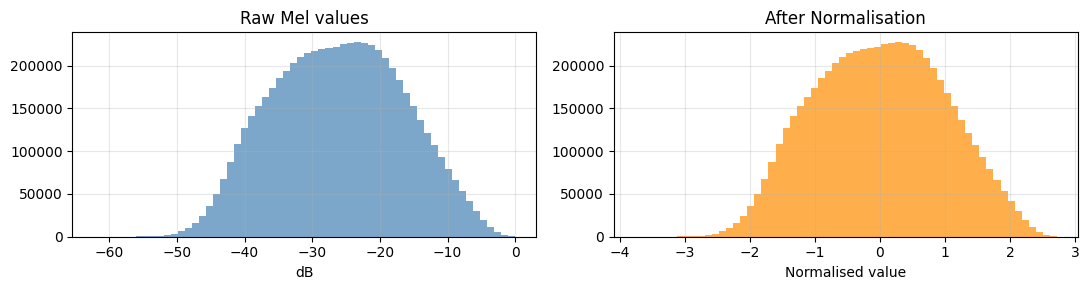

In [9]:
# distribution before vs after normalisation
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(X_train.flatten(), bins=60, color='steelblue', alpha=0.7)
axes[0].set_title('Raw Mel values')
axes[0].set_xlabel('dB')

axes[1].hist(X_train_norm.flatten(), bins=60, color='darkorange', alpha=0.7)
axes[1].set_title('After Normalisation')
axes[1].set_xlabel('Normalised value')

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

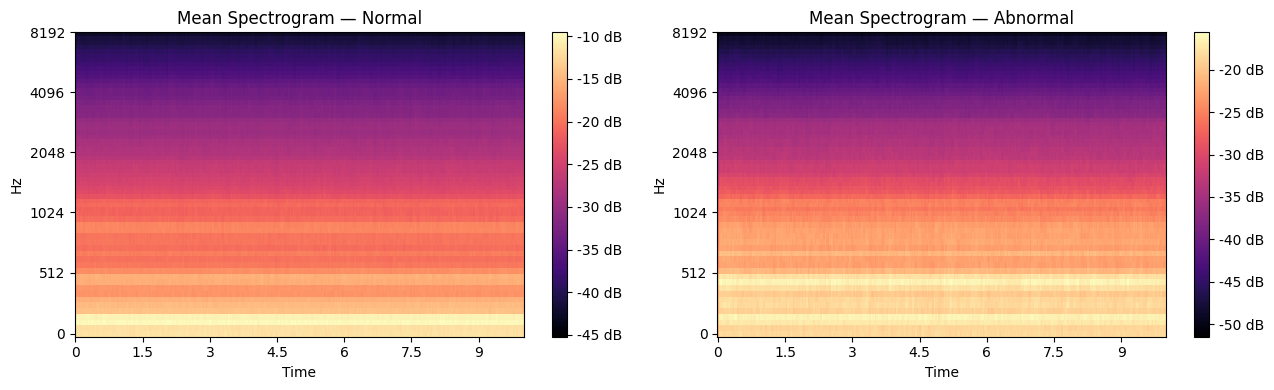

In [12]:
# compare mean spectrogram — normal vs abnormal
mean_normal   = X_normal.mean(axis=0)
mean_abnormal = X_abnormal.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
img1 = librosa.display.specshow(mean_normal, sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel', ax=axes[0])
axes[0].set_title('Mean Spectrogram — Normal')
fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')

img2 = librosa.display.specshow(mean_abnormal, sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('Mean Spectrogram — Abnormal')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

### 3.6 — Save processed data

In [13]:
out_path = os.path.join(OUT_DIR, 'mimii_processed.npz')
np.savez_compressed(
    out_path,
    X_train    = X_train_norm,
    X_val      = X_val_norm,
    X_abnormal = X_abnormal_norm,
    y_train    = np.zeros(len(X_train_norm),    dtype=np.int32),
    y_val      = np.zeros(len(X_val_norm),      dtype=np.int32),
    y_abnormal = np.ones(len(X_abnormal_norm),  dtype=np.int32),
    norm_mean  = np.array([mu]),
    norm_std   = np.array([sigma])
)
print(f'Saved: {out_path}')
print(f'  X_train    : {X_train_norm.shape}')
print(f'  X_val      : {X_val_norm.shape}')
print(f'  X_abnormal : {X_abnormal_norm.shape}')
print(f'  File size  : {os.path.getsize(out_path)/1e6:.1f} MB')

Saved: ../data/processed\mimii_processed.npz
  X_train    : (304, 64, 313)
  X_val      : (77, 64, 313)
  X_abnormal : (138, 64, 313)
  File size  : 37.3 MB


### 3.7 — Quick sanity check on saved file

In [14]:
d = np.load(out_path, allow_pickle=True)
print('Keys and shapes:')
for k in d.keys():
    print(f'  {k}: {d[k].shape}')

Keys and shapes:
  X_train: (304, 64, 313)
  X_val: (77, 64, 313)
  X_abnormal: (138, 64, 313)
  y_train: (304,)
  y_val: (77,)
  y_abnormal: (138,)
  norm_mean: (1,)
  norm_std: (1,)


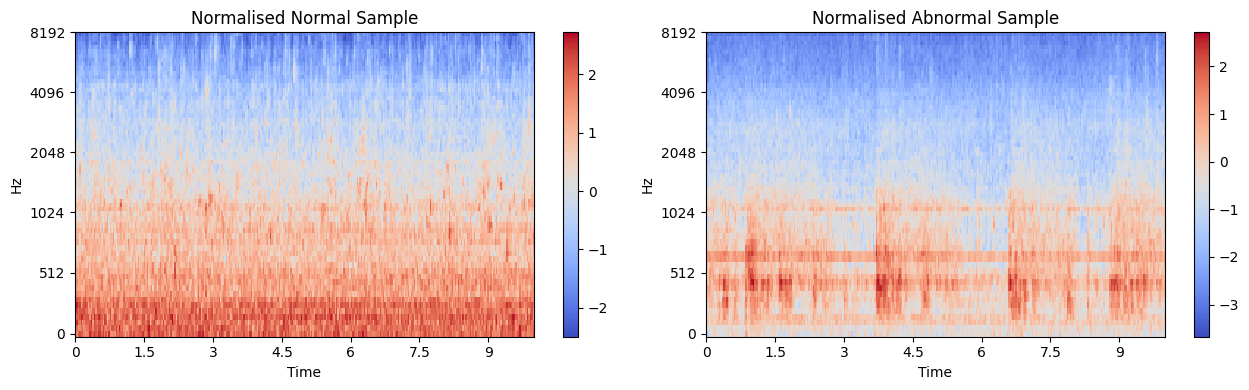

MIMII preprocessing done. Next: Step 4 — Model Training


In [15]:
# show a normalised train spectrogram and an abnormal one side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

img1 = librosa.display.specshow(d['X_train'][0], sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel', ax=axes[0])
axes[0].set_title('Normalised Normal Sample')
fig.colorbar(img1, ax=axes[0])

img2 = librosa.display.specshow(d['X_abnormal'][0], sr=SR, hop_length=HOP_LENGTH,
                                  x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('Normalised Abnormal Sample')
fig.colorbar(img2, ax=axes[1])

plt.tight_layout()
plt.show()

print('MIMII preprocessing done. Next: Step 4 — Model Training')